In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
# Load data from CSV file

def make_plot_for_country(country):

    train_data = pd.read_parquet("../data/{}/train.parquet".format(country))
    n_train = len(train_data)
    test_data = pd.read_parquet("../data/{}/test.parquet".format(country))
    n_test = len(test_data)
    n= n_train + n_test
    d = len(train_data.columns)

    methods = {'oracle_gap': {'csv' : 'oracle_gap', 'name': 'Oracle Poverty Gap Targeting'}, 
            'continuous_gap': {'csv': 'output_gt_continuous_gap','name': 'Poverty Gap Targeting (Continuous-Valued)'},
            'binary_gap': {'csv': 'output_gt_binary_gap', 'name': 'Poverty Gap Targeting (Binary-Valued)'},
            'continuous_rate': {'csv': 'output_gt_continuous_rate','name': 'Poverty Rate Targeting (Continuous-Valued)'},
            'binary_rate': {'csv': 'output_gt_binary_rate', 'name': 'Poverty Rate Targeting (Binary-Valued)'},
            'pmt': {'csv': 'pmt', 'name': 'PMT'},}

    conversion_factor = 1.0

    for method in methods:
        dic = methods[method]
        df = pd.read_csv('results/{}/{}.csv'.format(country, dic['csv']))
        df['method'] = dic['name']
        dic['df'] = df

    fontsize = 20

    pre_transfer_poverty_gap = max(methods['oracle_gap']['df']['post_transfer_poverty_gap'])


    # Plot policy_cost_per_capita vs post_transfer_poverty_rate
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))

    for method in methods:
        if "rate" in method:
            color = 'orange'
        if "gap" in method:
            color = 'blue'
        if "binary" in method:
            linestyle = '--'
        if "continuous" in method:
            linestyle = '-'
        if method== "pmt":
            color = "red"
            linestyle = '-'
        if method == "oracle_gap":
            color = "green"
            linestyle = '-'
        dic = methods[method]
        df = dic['df']
        ax[1].plot(df['post_transfer_poverty_rate'] * 100, df['policy_cost_per_capita'] * conversion_factor, marker='o', label=dic['name'], color=color, linestyle=linestyle)
        rate_interpolator = interp1d(df['post_transfer_poverty_rate'] * 100, df['policy_cost_per_capita'] * conversion_factor, kind='linear')
        ax[0].plot(df['post_transfer_poverty_gap'] * conversion_factor, df['policy_cost_per_capita'] * conversion_factor, marker='o', label=dic['name'], color=color, linestyle=linestyle)
        gap_interpolator = interp1d(df['post_transfer_poverty_gap'] * conversion_factor, df['policy_cost_per_capita'] * conversion_factor, kind='linear')
        #print(method, gap_interpolator(max()))
        print(method, gap_interpolator(pre_transfer_poverty_gap * conversion_factor * 0.05))
    ax[1].set_xlabel('Post-Transfer Poverty Rate (%)', fontsize=fontsize)
    ax[0].set_xlabel('Post-Transfer Poverty Gap (Per Capita Per Day 2017 PPP USD)', fontsize=fontsize)
        
    ax[1].set_title('Policy Cost vs Post-Transfer Poverty Rate', fontsize=fontsize)
    ax[0].set_title('Policy Cost vs Post-Transfer Poverty Gap', fontsize=fontsize)

    #ax[0].axvline(x=5, color="black", linestyle='--', label='5% Poverty Rate')
    ax[0].axvline(x=pre_transfer_poverty_gap * conversion_factor * 0.05, color="black", linestyle='--', label='5% Pre-Transfer Poverty Gap')

    for i in range(2):
        ax[i].legend(fontsize=fontsize)
        ax[i].set_ylabel('Policy Cost (Per Capita Per Day 2017 PPP USD)', fontsize=fontsize)
        ax[i].grid(True)
        ax[i].tick_params(axis='x', labelsize=15)  
        ax[i].tick_params(axis='y', labelsize=15)


    plt.suptitle('{} (n={}, d={}): Policy Cost vs. Post-Transfer Poverty Measure'.format(country, n, d), fontsize=fontsize + 2)
    plt.tight_layout()
    plt.savefig('figs/{}_policy_cost_vs_poverty_measure.pdf'.format(country, country))


oracle_gap 0.19392147697530251
continuous_gap 0.703301167109972
binary_gap 1.3267917114174712
continuous_rate 0.5971666980468023
binary_rate 1.332688324419958
pmt 1.9887201766622766


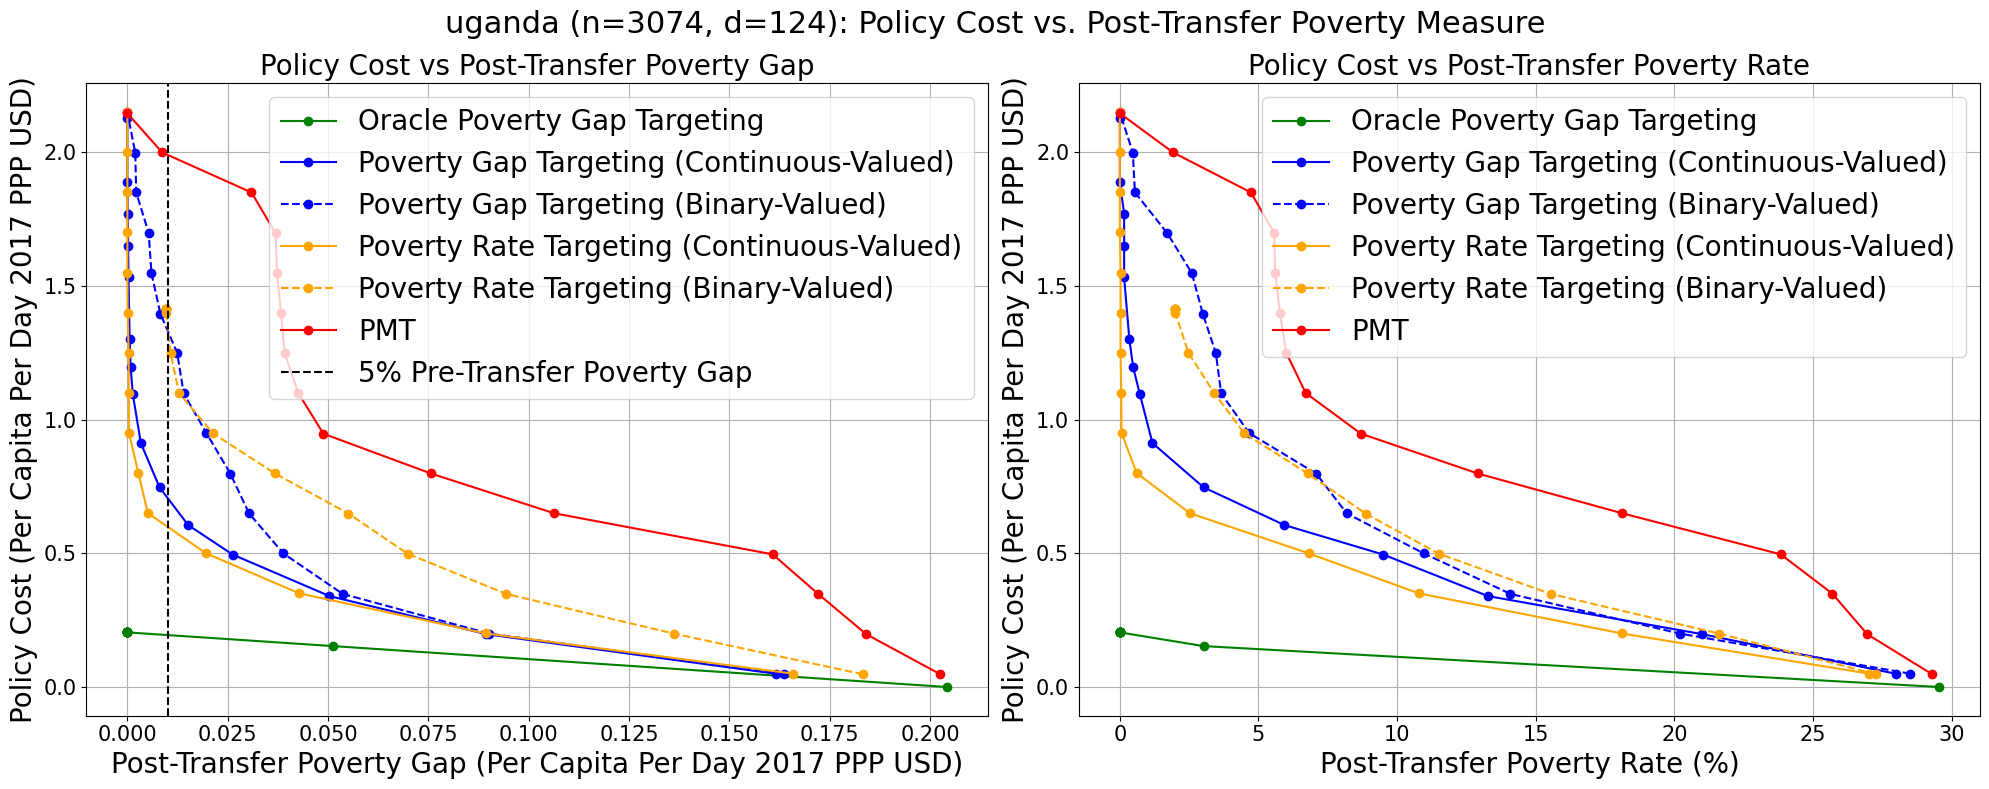

In [2]:
make_plot_for_country("uganda")

oracle_gap 0.5142718232511299
continuous_gap 1.0365401702068546
binary_gap 1.126571011268947
continuous_rate 1.140339064004634
binary_rate 1.287472904692839
pmt 1.5801077119781757


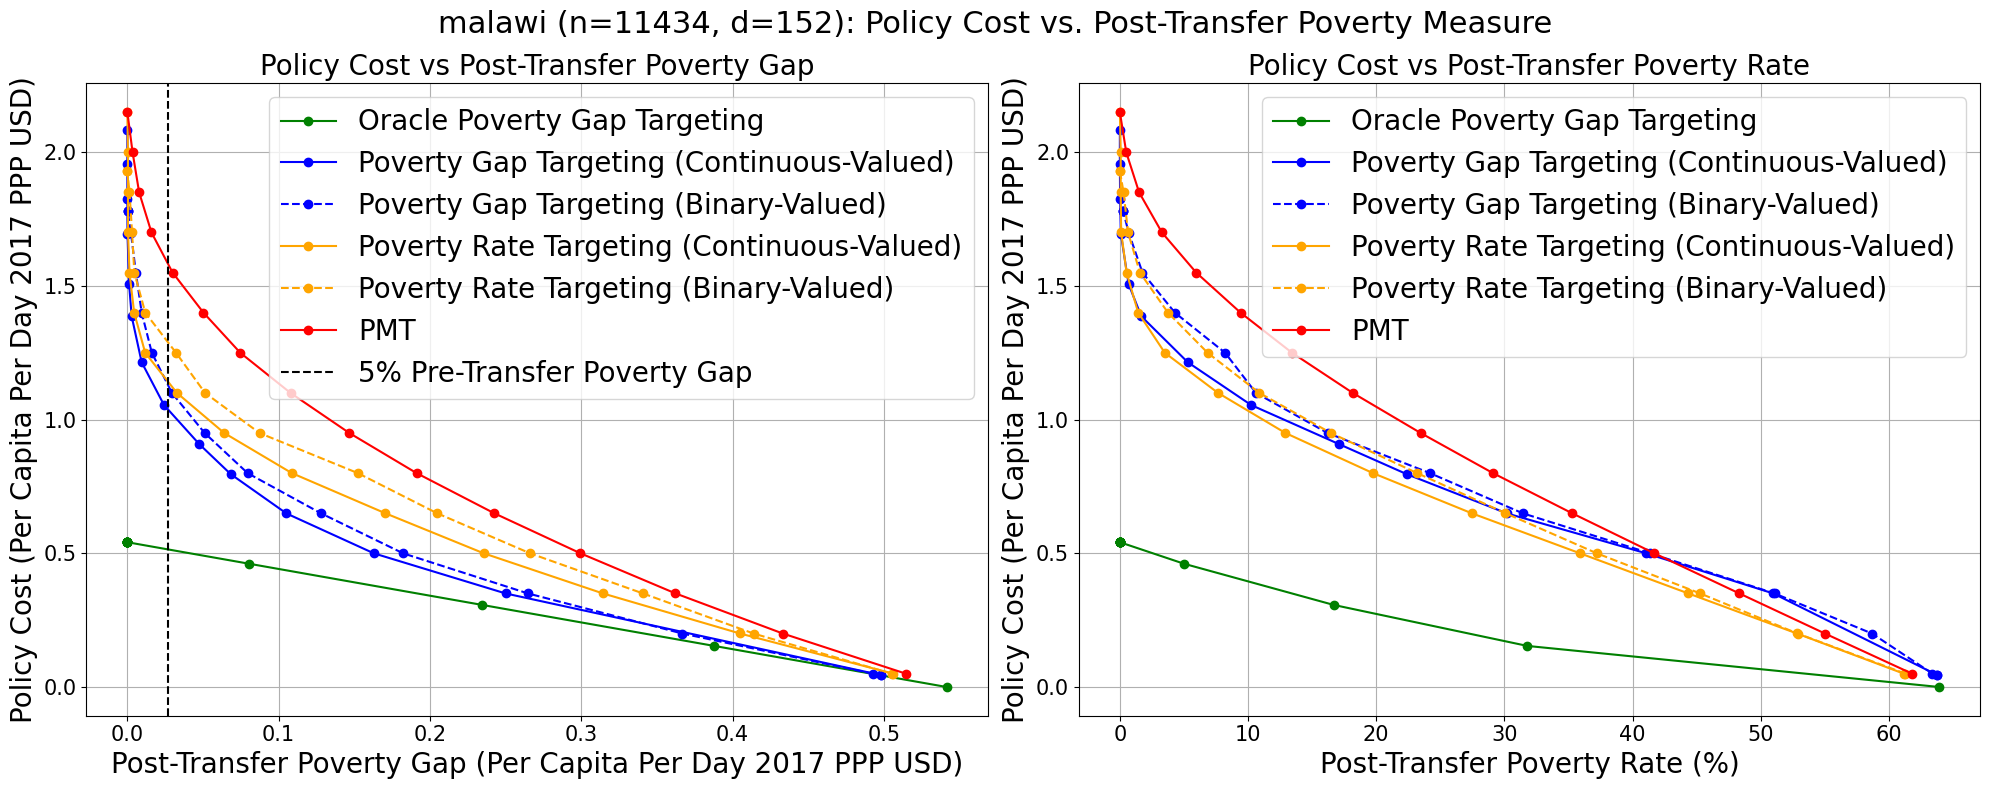

In [3]:
make_plot_for_country('malawi')

oracle_gap 0.27333356813275045
continuous_gap 0.8928007508185477
binary_gap 1.122381641539334
continuous_rate 1.1642623196539543
binary_rate 1.0959314562397837
pmt 1.6025939174145498


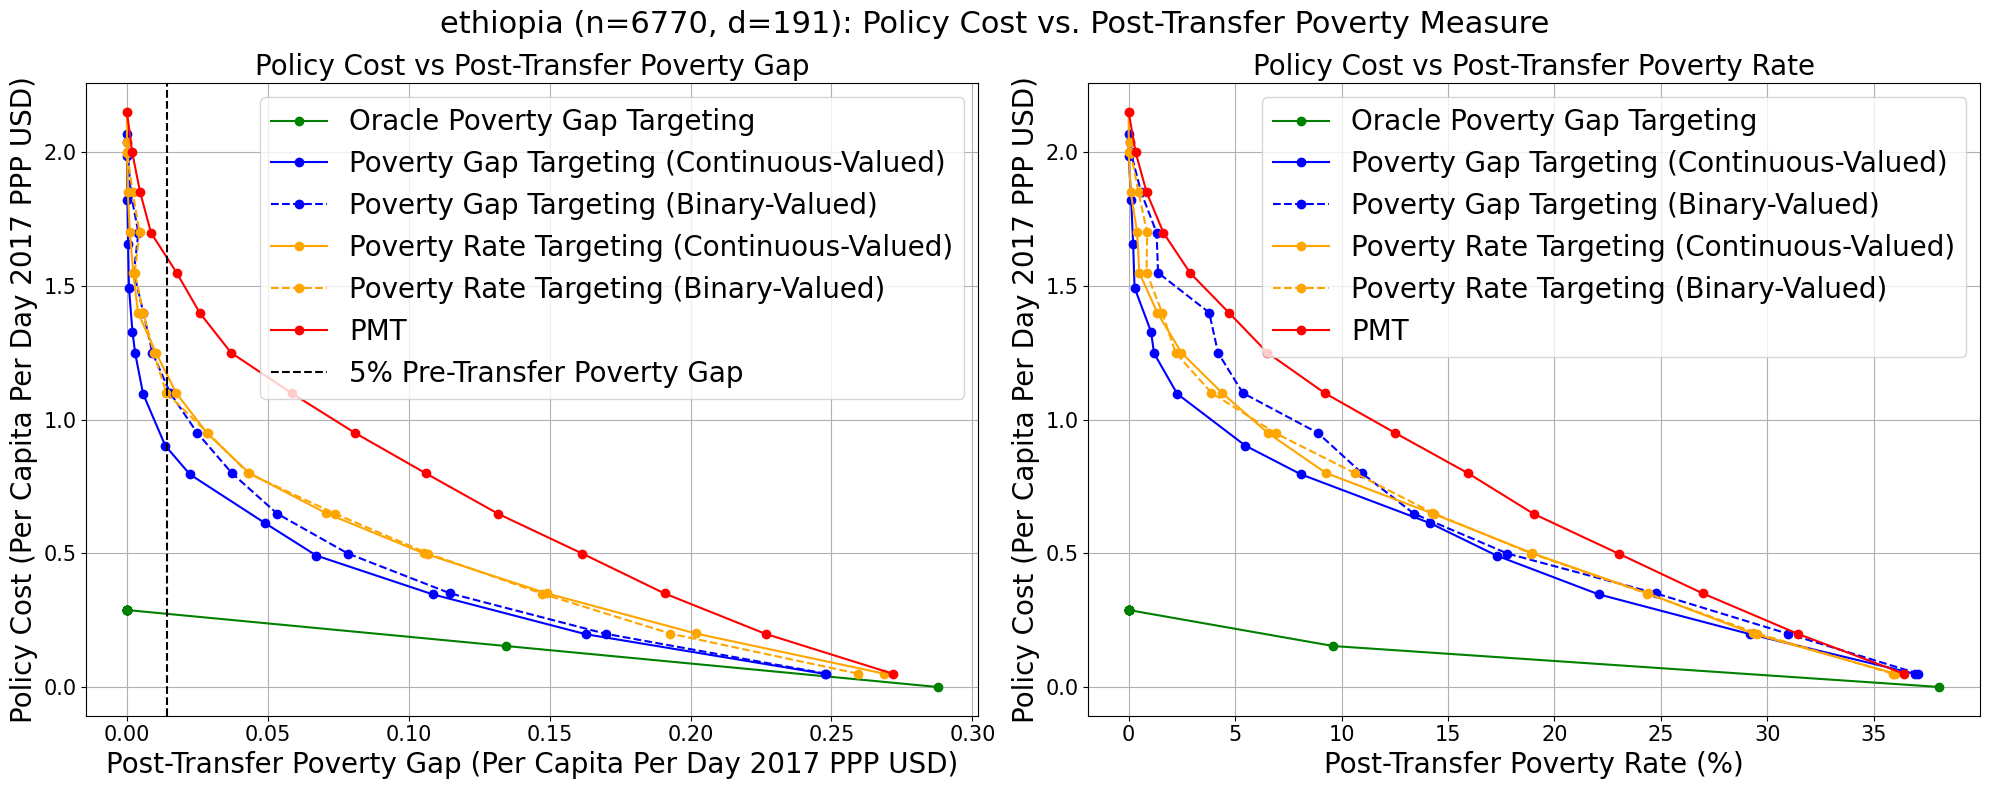

In [4]:
make_plot_for_country("ethiopia")

oracle_gap 0.09008602416027171
continuous_gap 0.4801308795413233
binary_gap 0.7343658566669978
continuous_rate 0.6466449909874723
binary_rate 0.7903089655726118
pmt 1.2726487808000013


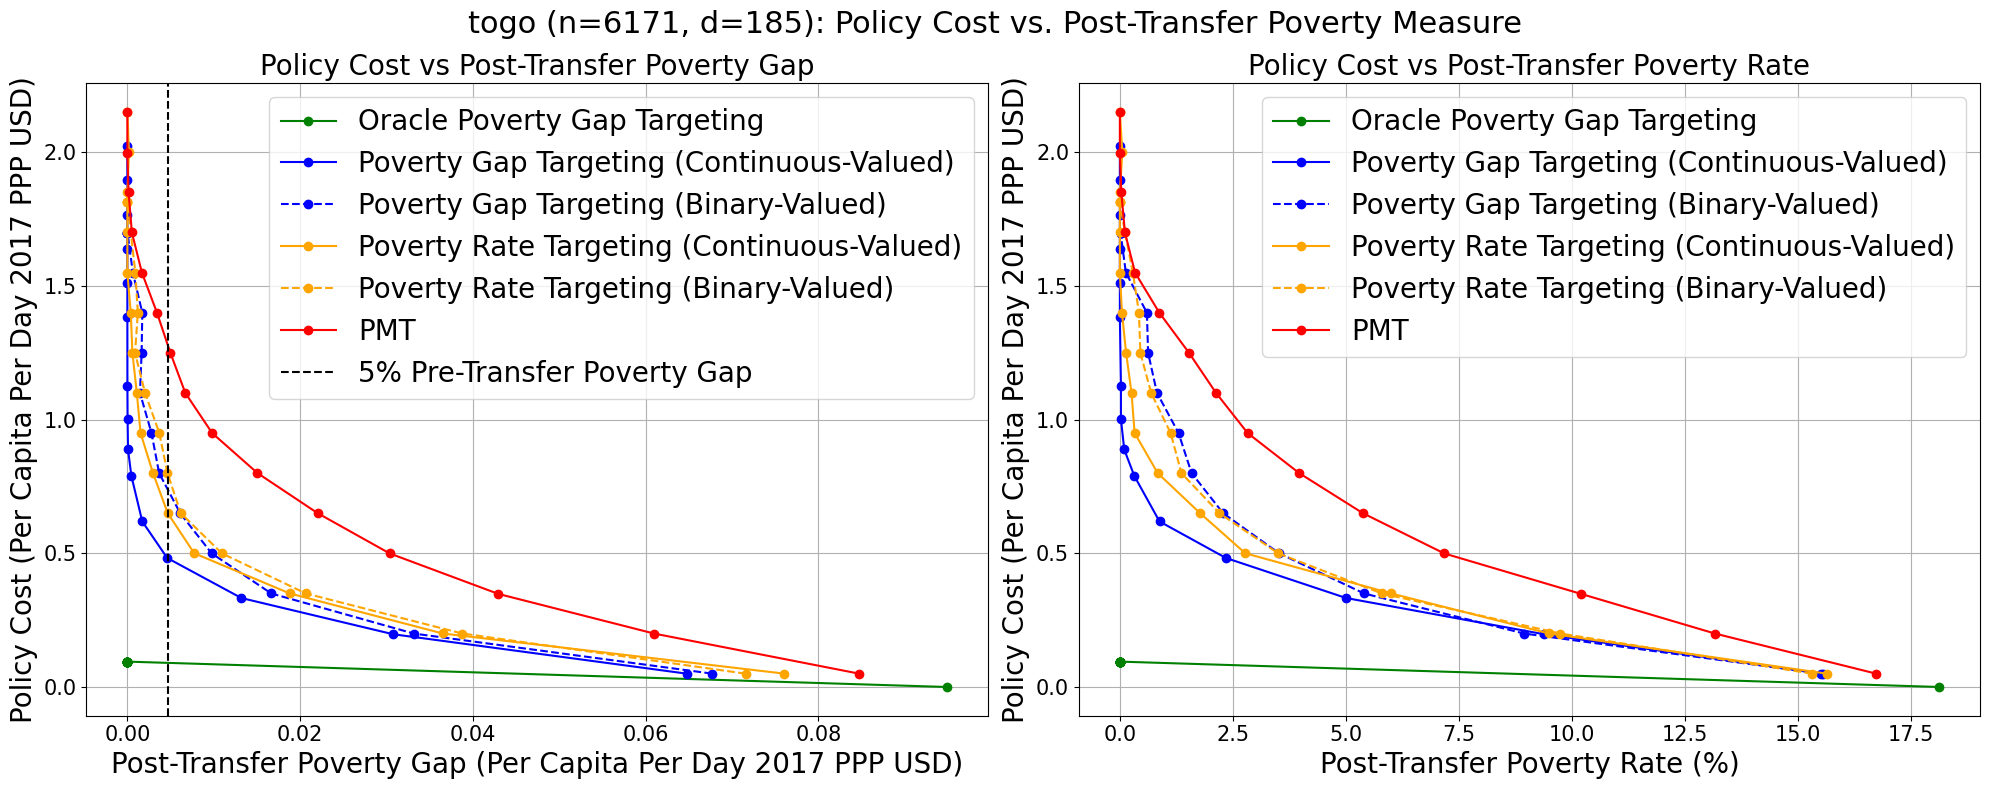

In [5]:
make_plot_for_country("togo")

oracle_gap 0.11408612434163239
continuous_gap 0.5267525826754049
binary_gap 0.9624390242443918
continuous_rate 0.5953750391914682
binary_rate 0.7379829599929384
pmt 1.2417572730914013


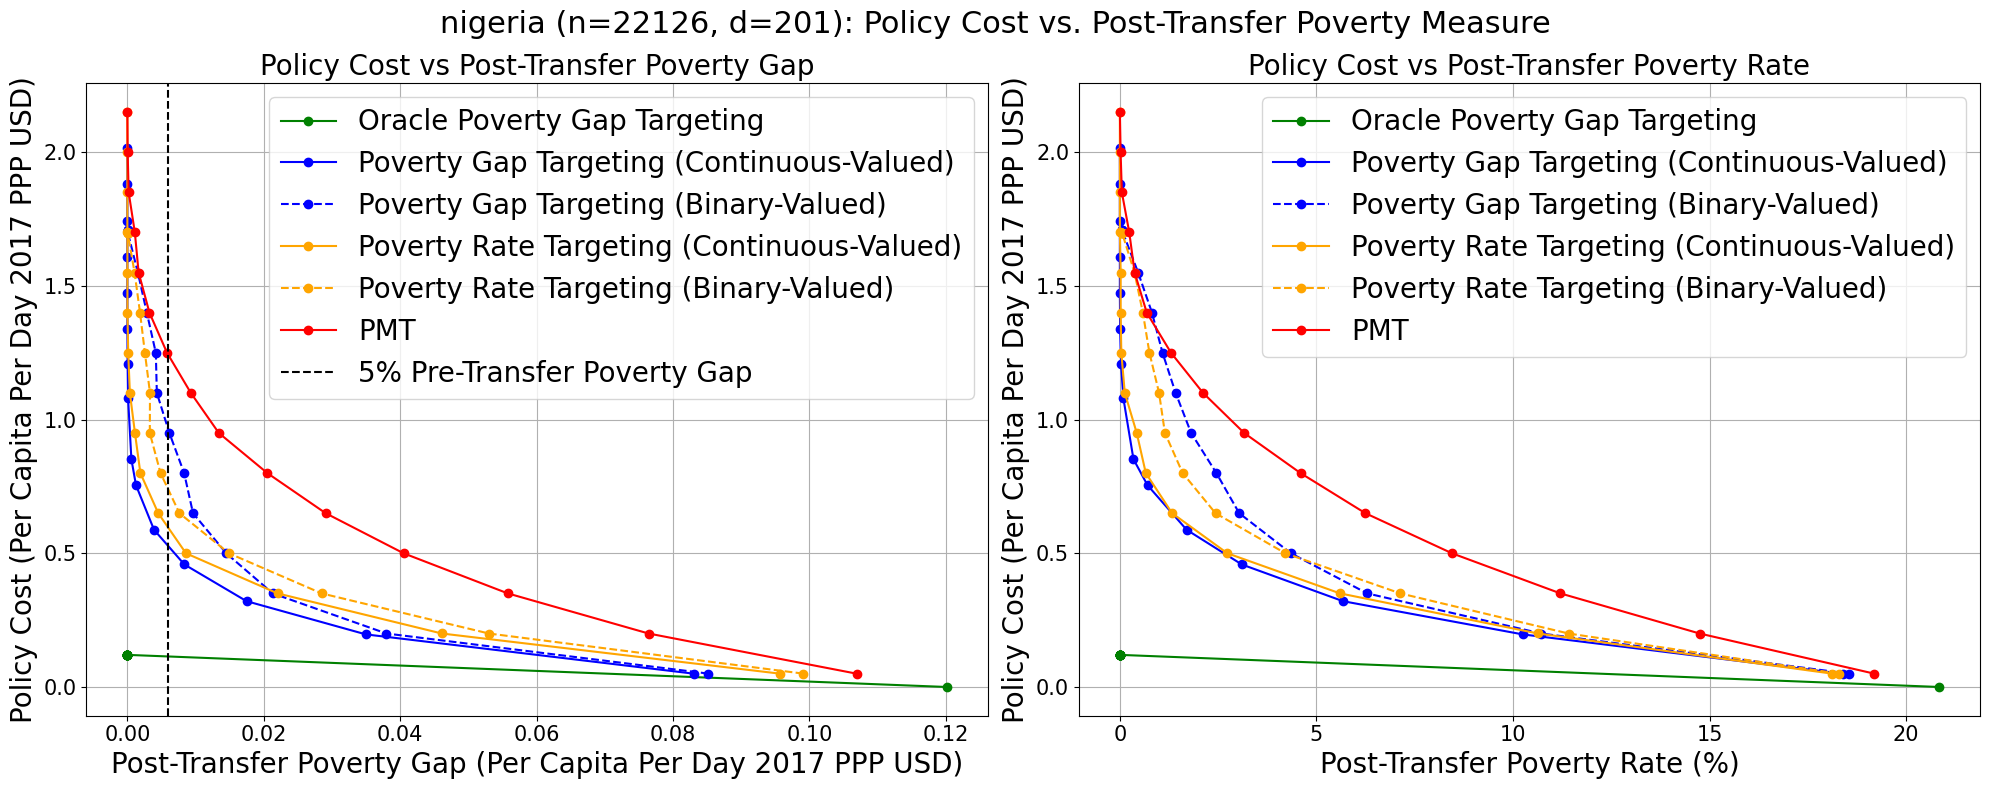

In [6]:
make_plot_for_country("nigeria")